<a href="https://colab.research.google.com/github/RafaelaMlucca/skin-lesion-classification-ham10000/blob/main/02_experiments_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto IA — HAM10000: Experimentos (v2, agressivo)

Mudanças em relação à v1:

**Modelo A — DINOv2 + SVM**
- Backbone **ViT-B/14** (embedding 768, vs 384 do ViT-S).
- **Busca de hiperparâmetros** do SVM (`C`, `gamma`) escolhida pela macro-F1 de **validação** (respeita o split por lesão); SVM final re-treinado em treino+val.

**Modelo B — EfficientNetV2-S (fine-tuning)**
- **Warmup**: 2 épocas treinando só a cabeça (backbone congelado), depois fine-tuning completo.
- **15 épocas**, **cosine LR**, **early stopping** pela macro-F1 de validação.
- **Class weights suavizados** (raiz da frequência inversa) → recupera recall de melanoma.
- **RandAugment** + **label smoothing** (regularização).
- **TTA** (test-time augmentation) na avaliação final.
- API de mixed precision atualizada (`torch.amp`).

> Rodar no **Colab com GPU T4**.

## 0. Setup

In [1]:
!pip install -q timm kagglehub

In [2]:
import os, time, copy, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
RESULTS_DIR = 'results'; os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda


## 1. Dados, rótulos e caminhos

In [3]:
import kagglehub
DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("DATA_DIR:", DATA_DIR)

df = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))
img_paths = {}
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith('.jpg'):
            img_paths[os.path.splitext(f)[0]] = os.path.join(root, f)
df['path'] = df['image_id'].map(img_paths)
df = df.dropna(subset=['path']).reset_index(drop=True)

CLASSES = sorted(df['dx'].unique().tolist())
CLASS_TO_IDX = {cl: i for i, cl in enumerate(CLASSES)}
df['label'] = df['dx'].map(CLASS_TO_IDX)
MEL_IDX = CLASS_TO_IDX['mel']
print('Imagens utilizáveis:', len(df), '| Classes:', CLASSES)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
DATA_DIR: /kaggle/input/skin-cancer-mnist-ham10000
Imagens utilizáveis: 10015 | Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## 2. Split agrupado por `lesion_id`

In [4]:
def grouped_split(frame, seed=SEED):
    idx = np.arange(len(frame)); y = frame['label'].values; g = frame['lesion_id'].values
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    trainval_pos, test_pos = next(sgkf.split(idx, y, g))
    tv = frame.iloc[trainval_pos].reset_index(drop=True)
    sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    tr_pos, val_pos = next(sgkf2.split(np.arange(len(tv)), tv['label'].values, tv['lesion_id'].values))
    return (tv.iloc[tr_pos].reset_index(drop=True),
            tv.iloc[val_pos].reset_index(drop=True),
            frame.iloc[test_pos].reset_index(drop=True))

train_df, val_df, test_df = grouped_split(df)
s_tr, s_val, s_te = set(train_df['lesion_id']), set(val_df['lesion_id']), set(test_df['lesion_id'])
assert not (s_tr & s_val) and not (s_tr & s_te) and not (s_val & s_te), 'VAZAMENTO de lesion_id!'
print(f'Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}')

Treino: 6409 | Val: 1592 | Teste: 2014


## 3. Transforms (com RandAugment) e Dataset

In [5]:
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD),
])

train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandAugment(num_ops=2, magnitude=7),
    T.ToTensor(), T.Normalize(MEAN, STD),
])

class HAMDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        return self.transform(img), int(row['label'])

## 4. Avaliação (com suporte a TTA)

In [6]:
def evaluate(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    cm   = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
    rec_mel = cm[MEL_IDX, MEL_IDX] / cm[MEL_IDX].sum() if cm[MEL_IDX].sum() else 0.0
    print(f'\n===== {name} =====')
    print(f'Acurácia: {acc:.3f} | Balanced acc: {bacc:.3f} | Macro-F1: {mf1:.3f} | Recall melanoma: {rec_mel:.3f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3, zero_division=0))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues'); fig.colorbar(im)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro'); ax.set_title(f'Matriz de confusão — {name}')
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, f'cm_{name}.png'), dpi=120); plt.show()
    return {'modelo': name, 'acuracia': acc, 'balanced_acc': bacc,
            'macro_f1': mf1, 'recall_melanoma': rec_mel}

@torch.no_grad()
def predict_loader(model, loader, tta=False):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
            prob = model(x).softmax(1)
            if tta:
                prob = prob + model(torch.flip(x, dims=[3])).softmax(1)  # flip horizontal
                prob = prob + model(torch.flip(x, dims=[2])).softmax(1)  # flip vertical
        ps.append(prob.argmax(1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

## 5. Modelo A — DINOv2 **ViT-B/14** (congelado) + SVM

In [7]:
backbone = timm.create_model('vit_base_patch14_dinov2.lvd142m',
                             pretrained=True, num_classes=0, img_size=IMG_SIZE)
backbone = backbone.eval().to(device)
for p in backbone.parameters():
    p.requires_grad_(False)
print('Dim do embedding:', backbone.num_features)

@torch.no_grad()
def extract_features(frame):
    loader = DataLoader(HAMDataset(frame, eval_tf), batch_size=64, shuffle=False, num_workers=2)
    feats, labels = [], []
    for x, y in loader:
        with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
            f = backbone(x.to(device))
        feats.append(f.float().cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print('Extraindo features ViT-B (alguns minutos)...')
Xtr, ytr = extract_features(train_df)
Xval, yval = extract_features(val_df)
Xte, yte = extract_features(test_df)
print('Shapes:', Xtr.shape, Xval.shape, Xte.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dim do embedding: 768
Extraindo features ViT-B (alguns minutos)...
Shapes: (6409, 768) (1592, 768) (2014, 768)


C=1    gamma=scale  -> val macro-F1 0.564
C=1    gamma=0.01   -> val macro-F1 0.128
C=1    gamma=0.001  -> val macro-F1 0.552
C=10   gamma=scale  -> val macro-F1 0.571
C=10   gamma=0.01   -> val macro-F1 0.116
C=10   gamma=0.001  -> val macro-F1 0.586
C=100  gamma=scale  -> val macro-F1 0.565
C=100  gamma=0.01   -> val macro-F1 0.116
C=100  gamma=0.001  -> val macro-F1 0.583

Melhor config (val): (0.58592353106799, 10, 0.001)

===== A_DINOv2-B_SVM =====
Acurácia: 0.805 | Balanced acc: 0.583 | Macro-F1: 0.601 | Recall melanoma: 0.536
              precision    recall  f1-score   support

       akiec      0.493     0.485     0.489        68
         bcc      0.566     0.690     0.622       100
         bkl      0.579     0.644     0.610       205
          df      0.600     0.136     0.222        22
         mel      0.541     0.536     0.538       222
          nv      0.921     0.911     0.916      1363
        vasc      1.000     0.676     0.807        34

    accuracy               

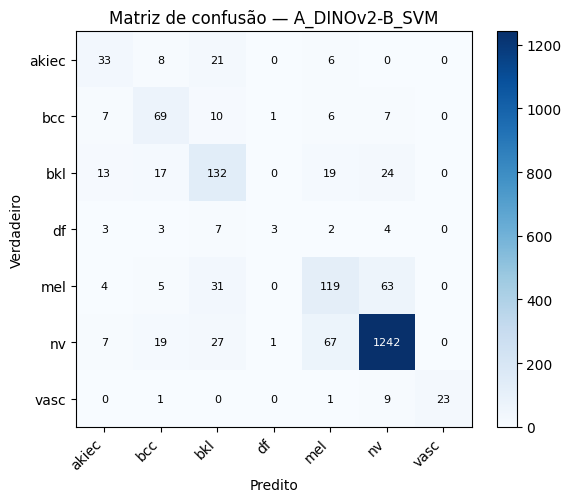

In [8]:
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xval_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xval), scaler.transform(Xte)

# Busca de C/gamma escolhida pela macro-F1 de validação (split por lesão)
best = (-1.0, None, None)
for C in [1, 10, 100]:
    for gamma in ['scale', 0.01, 0.001]:
        clf = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=SEED)
        clf.fit(Xtr_s, ytr)
        f1v = f1_score(yval, clf.predict(Xval_s), average='macro')
        print(f'C={C:<4} gamma={gamma!s:<6} -> val macro-F1 {f1v:.3f}')
        if f1v > best[0]:
            best = (f1v, C, gamma)
print('\nMelhor config (val):', best)

# SVM final re-treinado em treino+val
Xtrv = np.vstack([Xtr_s, Xval_s]); ytrv = np.concatenate([ytr, yval])
svm = SVC(kernel='rbf', C=best[1], gamma=best[2], class_weight='balanced', random_state=SEED)
svm.fit(Xtrv, ytrv)
res_A = evaluate(yte, svm.predict(Xte_s), 'A_DINOv2-B_SVM')

## 6. Modelo B — EfficientNetV2-S (warmup → fine-tuning, cosine, TTA)

In [13]:
BATCH = 32; WARMUP = 2; EPOCHS = 30; LR_HEAD = 1e-3; LR_FULL = 1e-4; PATIENCE = 4

train_loader = DataLoader(HAMDataset(train_df, train_tf), batch_size=BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(HAMDataset(val_df, eval_tf),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(HAMDataset(test_df, eval_tf),  batch_size=BATCH, shuffle=False, num_workers=2)

# Class weights SUAVIZADOS (raiz da inversa), normalizados em torno de 1
counts = train_df['label'].value_counts().sort_index().values
w = (counts.sum() / (len(counts) * counts)) ** 0.5
class_w = torch.tensor(w / w.mean(), dtype=torch.float32).to(device)
print('Pesos por classe:', dict(zip(CLASSES, class_w.cpu().numpy().round(2))))

model_b = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k',
                            pretrained=True, num_classes=len(CLASSES)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
scaler_amp = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))

def run_epoch(model, loader, optimizer):
    model.train(); total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
            loss = criterion(model(x), y)
        scaler_amp.scale(loss).backward(); scaler_amp.step(optimizer); scaler_amp.update()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

def val_macro_f1(model):
    yv, pv = predict_loader(model, val_loader, tta=False)
    return f1_score(yv, pv, average='macro')

Pesos por classe: {'akiec': np.float32(1.1), 'bcc': np.float32(0.85), 'bkl': np.float32(0.59), 'df': np.float32(1.78), 'mel': np.float32(0.59), 'nv': np.float32(0.24), 'vasc': np.float32(1.85)}


In [14]:
best_f1, best_state, no_improve = -1.0, None, 0

# ---- Fase 1: warmup (só a cabeça) ----
for p in model_b.parameters():
    p.requires_grad_(False)
for p in model_b.get_classifier().parameters():
    p.requires_grad_(True)
opt = torch.optim.AdamW([p for p in model_b.parameters() if p.requires_grad], lr=LR_HEAD)
for epoch in range(WARMUP):
    t0 = time.time(); loss = run_epoch(model_b, train_loader, opt); vf1 = val_macro_f1(model_b)
    print(f'[warmup {epoch+1}/{WARMUP}] loss {loss:.3f} | val macro-F1 {vf1:.3f} | {time.time()-t0:.0f}s')
    if vf1 > best_f1: best_f1, best_state = vf1, copy.deepcopy(model_b.state_dict())

# ---- Fase 2: fine-tuning completo + cosine ----
for p in model_b.parameters():
    p.requires_grad_(True)
opt = torch.optim.AdamW(model_b.parameters(), lr=LR_FULL, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS - WARMUP)
for epoch in range(WARMUP, EPOCHS):
    t0 = time.time(); loss = run_epoch(model_b, train_loader, opt); vf1 = val_macro_f1(model_b)
    sched.step()
    print(f'[full {epoch+1}/{EPOCHS}] loss {loss:.3f} | val macro-F1 {vf1:.3f} | lr {sched.get_last_lr()[0]:.2e} | {time.time()-t0:.0f}s')
    if vf1 > best_f1:
        best_f1, best_state, no_improve = vf1, copy.deepcopy(model_b.state_dict()), 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping (sem melhora por {PATIENCE} épocas).'); break

model_b.load_state_dict(best_state)
print('Melhor val macro-F1:', round(best_f1, 3))

[warmup 1/2] loss 6.187 | val macro-F1 0.220 | 77s
[warmup 2/2] loss 4.716 | val macro-F1 0.268 | 74s
[full 3/30] loss 2.650 | val macro-F1 0.438 | lr 9.97e-05 | 85s
[full 4/30] loss 1.392 | val macro-F1 0.535 | lr 9.87e-05 | 85s
[full 5/30] loss 1.249 | val macro-F1 0.591 | lr 9.72e-05 | 86s
[full 6/30] loss 1.136 | val macro-F1 0.645 | lr 9.50e-05 | 85s
[full 7/30] loss 1.064 | val macro-F1 0.670 | lr 9.23e-05 | 92s
[full 8/30] loss 0.990 | val macro-F1 0.668 | lr 8.91e-05 | 85s
[full 9/30] loss 0.952 | val macro-F1 0.684 | lr 8.54e-05 | 86s
[full 10/30] loss 0.912 | val macro-F1 0.665 | lr 8.12e-05 | 86s
[full 11/30] loss 0.886 | val macro-F1 0.691 | lr 7.66e-05 | 85s
[full 12/30] loss 0.846 | val macro-F1 0.690 | lr 7.17e-05 | 86s
[full 13/30] loss 0.813 | val macro-F1 0.725 | lr 6.65e-05 | 86s
[full 14/30] loss 0.793 | val macro-F1 0.704 | lr 6.11e-05 | 86s
[full 15/30] loss 0.779 | val macro-F1 0.681 | lr 5.56e-05 | 84s
[full 16/30] loss 0.745 | val macro-F1 0.692 | lr 5.00e-05 |


===== B_EffNetV2_TTA =====
Acurácia: 0.841 | Balanced acc: 0.688 | Macro-F1: 0.685 | Recall melanoma: 0.559
              precision    recall  f1-score   support

       akiec      0.592     0.662     0.625        68
         bcc      0.764     0.810     0.786       100
         bkl      0.643     0.668     0.656       205
          df      0.545     0.273     0.364        22
         mel      0.623     0.559     0.589       222
          nv      0.926     0.931     0.929      1363
        vasc      0.795     0.912     0.849        34

    accuracy                          0.841      2014
   macro avg      0.698     0.688     0.685      2014
weighted avg      0.838     0.841     0.839      2014



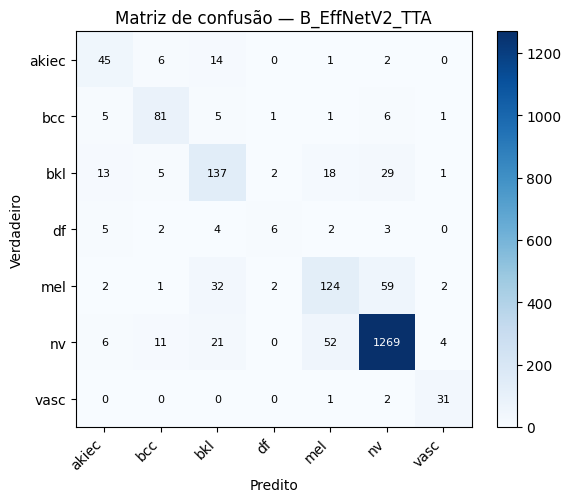

In [15]:
# Avaliação final com TTA
yte_b, pred_te_B = predict_loader(model_b, test_loader, tta=True)
res_B = evaluate(yte_b, pred_te_B, 'B_EffNetV2_TTA')

## 7. Comparação final

                acuracia  balanced_acc  macro_f1  recall_melanoma
modelo                                                           
A_DINOv2-B_SVM     0.805         0.583     0.601            0.536
B_EffNetV2_TTA     0.841         0.688     0.685            0.559


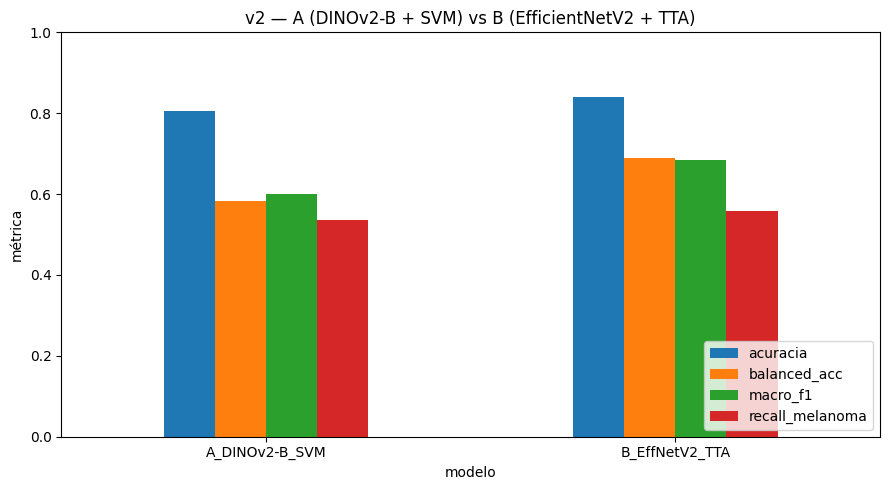

In [16]:
comp = pd.DataFrame([res_A, res_B]).set_index('modelo').round(3)
comp.to_csv(os.path.join(RESULTS_DIR, 'comparacao_modelos_v2.csv'))
print(comp)

comp[['acuracia', 'balanced_acc', 'macro_f1', 'recall_melanoma']].plot(kind='bar', figsize=(9, 5))
plt.title('v2 — A (DINOv2-B + SVM) vs B (EfficientNetV2 + TTA)')
plt.ylabel('métrica'); plt.xticks(rotation=0); plt.ylim(0, 1); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, 'comparacao_modelos_v2.png'), dpi=120); plt.show()